# 🎵 Song Year Prediction — End-to-End Regression Pipeline
**Midterm Assignment — Machine Learning Class**

| | |
|---|---|
| **Nama** | `Mohammad Fauzi Hadiwijaya` |
| **NIM** | `101032300044` |
| **Kelas** | `TK-47-04` |

---
## Pipeline Overview
1. Setup & Install Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Feature Engineering
5. MLflow Setup
6. Baseline Models
7. Hyperparameter Tuning dengan Optuna
8. Evaluasi & Perbandingan Model
9. Interpretasi dengan LIME
10. MLflow Tracking Summary

## 1. Setup & Install Libraries

In [ ]:
!pip install xgboost optuna mlflow lime --quiet
print('✅ Libraries installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.2 MB/s eta 0:00:00
   ━━

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# LIME
import lime
import lime.lime_tabular

SEED = 42
np.random.seed(SEED)

print('✅ All libraries imported!')
print(f'   Optuna  : {optuna.__version__}')
print(f'   MLflow  : {mlflow.__version__}')
print(f'   LIME    : installed ✅')

✅ All libraries imported!
   Optuna  : 4.8.0
   MLflow  : 3.12.0
   LIME    : installed ✅


## 2. Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/midterm-m1/midterm-regresi-dataset.csv'

print('📂 Loading dataset...')

df = pd.read_csv(DATA_PATH, header=None, nrows=50000)  # ← ini yang berubah, tambah nrows=50000

n_features = df.shape[1] - 1
df.columns = ['year'] + [f'feature_{i}' for i in range(1, n_features + 1)]

print(f'✅ Dataset shape : {df.shape}')
print(f'   Jumlah fitur  : {n_features}')
print(f'   Target        : year (tahun rilis lagu)')
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Loading dataset...
✅ Dataset shape : (50000, 91)
   Jumlah fitur  : 90
   Target        : year (tahun rilis lagu)


,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


## 3. Exploratory Data Analysis (EDA)

In [ ]:
print('=== Statistik Deskriptif ===')
display(df.describe())

=== Statistik Deskriptif ===


,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1998.414820,43.443744,2.237652,8.383934,1.253447,-6.598275,-9.438598,-2.326890,-1.894335,3.861437,...,15.756412,-71.473070,40.837799,39.830572,0.463504,17.676146,-22.962413,4.410428,19.024254,1.450270
std,10.654326,6.003587,50.291949,35.121654,16.306163,22.513187,12.952502,14.260335,7.947267,10.491878,...,31.860961,171.811762,122.434388,95.675945,15.824909,112.416517,174.190665,13.327111,187.768990,22.048976
min,1922.000000,4.418500,-284.908360,-257.525600,-120.723150,-126.007560,-61.602380,-165.322690,-55.613470,-119.487530,...,-424.517570,-2334.760570,-1256.181470,-1412.660510,-198.622200,-2343.894110,-3026.006600,-233.456480,-5000.654060,-318.223330
25%,1995.000000,40.059883,-24.749578,-11.528742,-8.581275,-20.670452,-18.474588,-10.575005,-6.581295,-2.201135,...,-1.750645,-136.835525,-21.667925,-3.907622,-6.549855,-31.854488,-99.525968,-2.630273,-61.485285,-8.882668
50%,2002.000000,44.281150,9.491935,10.032470,-0.500905,-6.046040,-11.094885,-1.941585,-1.841990,3.834450,...,8.993295,-51.930760,28.048425,34.337955,0.835410,15.080735,-19.195265,3.033755,6.783110,0.063455
75%,2006.000000,47.856397,36.530960,29.359935,8.999335,7.750628,-2.183545,6.515710,2.795567,9.982812,...,25.916465,13.791208,88.437528,78.824185,8.358128,67.650225,54.193520,9.870532,84.998905,9.852172
max,2010.000000,57.302730,304.266390,260.150700,155.737220,262.068870,119.815590,116.914350,77.730830,86.752810,...,587.732680,1672.084480,2758.579760,1482.642140,191.193350,1175.094790,2833.608950,229.888800,4166.942890,378.662140


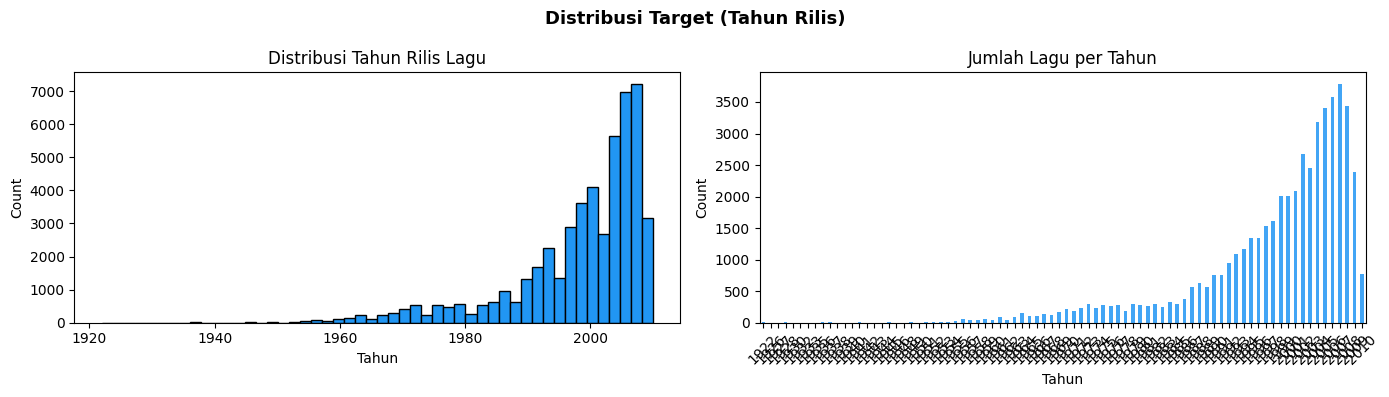

Tahun minimum : 1922
Tahun maksimum: 2010
Rata-rata     : 1998.4


In [ ]:
# Distribusi target: tahun rilis lagu
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['year'], bins=50, color='#2196F3', edgecolor='black')
axes[0].set_title('Distribusi Tahun Rilis Lagu')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Count')

df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#42A5F5')
axes[1].set_title('Jumlah Lagu per Tahun')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Distribusi Target (Tahun Rilis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Tahun minimum : {df["year"].min()}')
print(f'Tahun maksimum: {df["year"].max()}')
print(f'Rata-rata     : {df["year"].mean():.1f}')

In [ ]:
# Missing values
missing = df.isnull().sum().sum()
print(f'Total missing values: {missing}')
if missing == 0:
    print('✅ Tidak ada missing values!')

Total missing values: 0
✅ Tidak ada missing values!


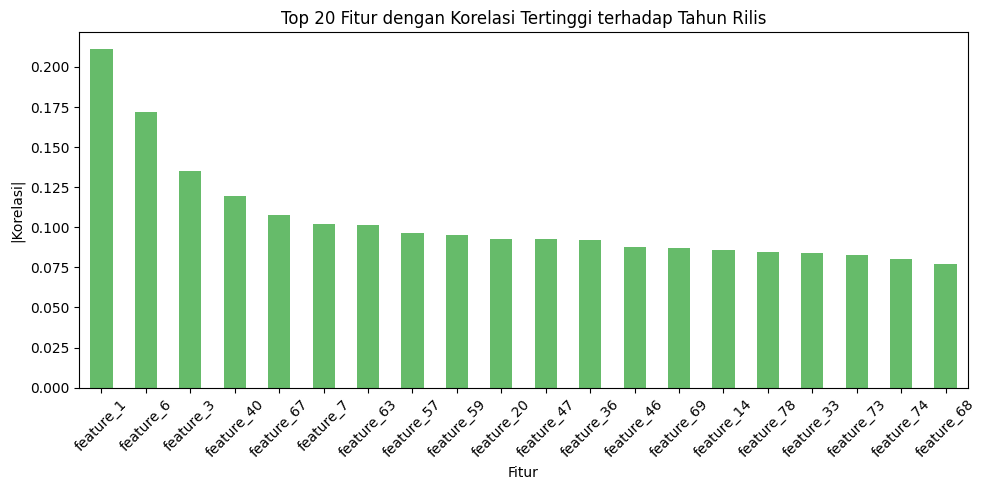

Top 10 fitur paling berkorelasi:
feature_1     0.211023
feature_6     0.171749
feature_3     0.134848
feature_40    0.119704
feature_67    0.107525
feature_7     0.101768
feature_63    0.101482
feature_57    0.096292
feature_59    0.095113
feature_20    0.092746
Name: year, dtype: float64


In [ ]:
# Korelasi fitur dengan target
corr_with_target = df.corr()['year'].drop('year').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
corr_with_target.head(20).plot(kind='bar', color='#66BB6A')
plt.title('Top 20 Fitur dengan Korelasi Tertinggi terhadap Tahun Rilis')
plt.ylabel('|Korelasi|')
plt.xlabel('Fitur')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Top 10 fitur paling berkorelasi:')
print(corr_with_target.head(10))

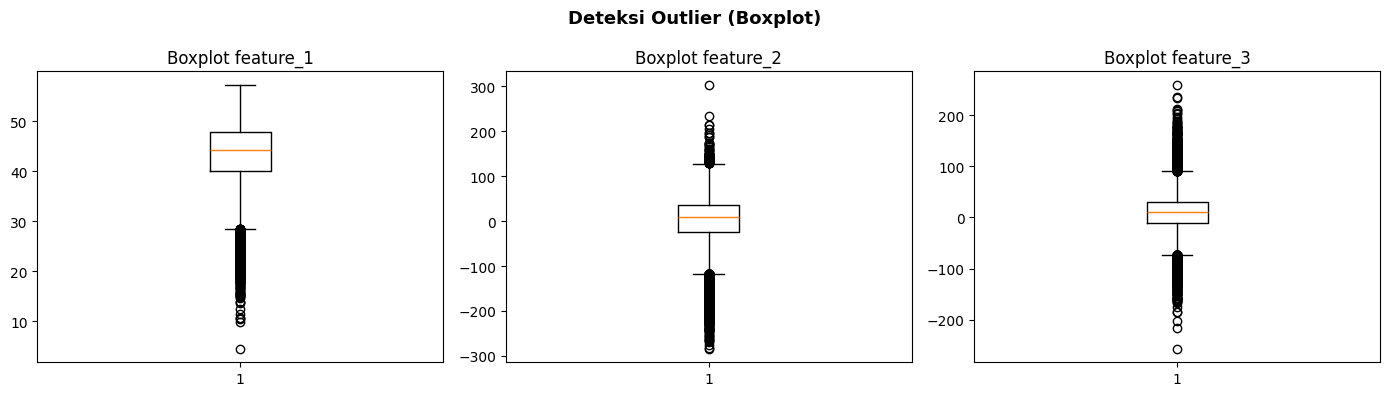

In [ ]:
# Deteksi outlier pada beberapa fitur utama
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['feature_1', 'feature_2', 'feature_3']):
    ax.boxplot(df[col].dropna())
    ax.set_title(f'Boxplot {col}')
plt.suptitle('Deteksi Outlier (Boxplot)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Feature Engineering

In [ ]:
# Pisahkan fitur dan target
X = df.drop(columns=['year'])
y = df['year']

feature_names = X.columns.tolist()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (50000, 90)
y shape: (50000,)


In [ ]:
# Handle outlier dengan IQR clipping
def clip_outliers(df, cols, multiplier=3.0):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        df[col] = df[col].clip(lower, upper)
    return df

X = clip_outliers(X, feature_names)
print('✅ Outlier clipping selesai (IQR x3)')

✅ Outlier clipping selesai (IQR x3)


In [ ]:
# Imputasi (jaga-jaga jika ada NaN)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print('✅ Imputasi & scaling selesai')

✅ Imputasi & scaling selesai


In [ ]:
# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED
)

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')

X_train : (40000, 90)
X_val   : (10000, 90)


## 5. MLflow Setup

In [ ]:
EXPERIMENT_NAME = 'song-year-regression'
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'✅ MLflow experiment: "{EXPERIMENT_NAME}"')
print(f'   Tracking URI: {mlflow.get_tracking_uri()}')

2026/05/08 05:53:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/08 05:53:09 INFO mlflow.store.db.utils: Updating database tables
2026/05/08 05:53:12 INFO mlflow.tracking.fluent: Experiment with name 'song-year-regression' does not exist. Creating a new experiment.


✅ MLflow experiment: "song-year-regression"
   Tracking URI: sqlite:////content/mlflow.db


In [ ]:
# Helper: evaluasi + log ke MLflow
results = {}

def log_and_evaluate(run_name, model, params, X_tr, y_tr, X_v, y_v):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_v)

        mse  = mean_squared_error(y_v, y_pred)
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(y_v, y_pred)
        r2   = r2_score(y_v, y_pred)

        mlflow.log_metrics({'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

        if isinstance(model, XGBRegressor):
            mlflow.xgboost.log_model(model, artifact_path='model')
        else:
            mlflow.sklearn.log_model(model, artifact_path='model')

        run_id = mlflow.active_run().info.run_id

    results[run_name] = {
        'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
        'model': model, 'run_id': run_id, 'y_pred': y_pred
    }

    print(f'\n===== {run_name} =====')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  MSE  : {mse:.4f}')
    print(f'  MLflow Run ID: {run_id}')
    return model

print('✅ Helper function siap')

✅ Helper function siap


## 6. Baseline Models

In [ ]:
# Baseline 1: Ridge Regression
print('Training Ridge Regression (baseline)...')
ridge_params = {'alpha': 1.0, 'random_state': SEED}
ridge = Ridge(**ridge_params)
log_and_evaluate('Ridge_baseline', ridge, ridge_params, X_train, y_train, X_val, y_val)

Training Ridge Regression (baseline)...


2026/05/08 05:53:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 05:53:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



===== Ridge_baseline =====
  RMSE : 9.2566
  MAE  : 6.6238
  R²   : 0.2221
  MSE  : 85.6853
  MLflow Run ID: e3454c8061114613be8f7e4fc7ce4bb1


Ridge(random_state=42)

In [ ]:
# Baseline 2: Random Forest
print('Training Random Forest (baseline)...')
rf_params = {'n_estimators': 100, 'max_depth': 10, 'random_state': SEED}
rf = RandomForestRegressor(**rf_params, n_jobs=-1)
log_and_evaluate('RF_baseline', rf, rf_params, X_train, y_train, X_val, y_val)

Training Random Forest (baseline)...


2026/05/08 05:59:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 05:59:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



===== RF_baseline =====
  RMSE : 9.1106
  MAE  : 6.5389
  R²   : 0.2465
  MSE  : 83.0034
  MLflow Run ID: 4f1cbe25172749cba9037df1559f7794


RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [ ]:
# Baseline 3: XGBoost
print('Training XGBoost (baseline)...')
xgb_params = {
    'n_estimators': 200, 'max_depth': 6,
    'learning_rate': 0.05, 'subsample': 0.8,
    'colsample_bytree': 0.8, 'random_state': SEED
}
xgb = XGBRegressor(**xgb_params, n_jobs=-1)
log_and_evaluate('XGB_baseline', xgb, xgb_params, X_train, y_train, X_val, y_val)

Training XGBoost (baseline)...


2026/05/08 05:59:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



===== XGB_baseline =====
  RMSE : 8.6746
  MAE  : 6.1445
  R²   : 0.3169
  MSE  : 75.2495
  MLflow Run ID: 6628b386aa4848ce82e2d88f5e6abe4a


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

## 7. Hyperparameter Tuning dengan Optuna

In [ ]:
# Optuna: Random Forest
def objective_rf(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 50, 300),
        'max_depth'        : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state'     : SEED, 'n_jobs': -1
    }
    model = RandomForestRegressor(**params)
    kf    = KFold(n_splits=3, shuffle=True, random_state=SEED)
    score = cross_val_score(model, X_train, y_train, cv=kf,
                            scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    return score  # maximize (neg RMSE)

print('🔍 Optuna tuning Random Forest (20 trials)...')
study_rf = optuna.create_study(direction='maximize', study_name='RF_regression')
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)

print(f'\n✅ Best RF RMSE (CV): {-study_rf.best_value:.4f}')
print(f'Best params: {study_rf.best_params}')

🔍 Optuna tuning Random Forest (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]


✅ Best RF RMSE (CV): 9.3004
Best params: {'n_estimators': 265, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt'}


In [ ]:
best_rf_params = {**study_rf.best_params, 'random_state': SEED, 'n_jobs': -1}
best_rf = RandomForestRegressor(**best_rf_params)
log_and_evaluate('RF_optuna', best_rf, best_rf_params, X_train, y_train, X_val, y_val)
print('✅ RF Optuna selesai')

2026/05/08 06:45:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 06:45:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



===== RF_optuna =====
  RMSE : 9.0168
  MAE  : 6.5403
  R²   : 0.2619
  MSE  : 81.3020
  MLflow Run ID: 33e8245f50c34c92b7e2ea66cad3bbf5
✅ RF Optuna selesai


In [ ]:
# Optuna: XGBoost
def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state'     : SEED, 'n_jobs': -1
    }
    model = XGBRegressor(**params)
    kf    = KFold(n_splits=3, shuffle=True, random_state=SEED)
    score = cross_val_score(model, X_train, y_train, cv=kf,
                            scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    return score

print('🔍 Optuna tuning XGBoost (20 trials)...')
study_xgb = optuna.create_study(direction='maximize', study_name='XGB_regression')
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

print(f'\n✅ Best XGB RMSE (CV): {-study_xgb.best_value:.4f}')
print(f'Best params: {study_xgb.best_params}')

🔍 Optuna tuning XGBoost (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]


✅ Best XGB RMSE (CV): 8.8312
Best params: {'n_estimators': 257, 'max_depth': 9, 'learning_rate': 0.03946439279323705, 'subsample': 0.9396920322012453, 'colsample_bytree': 0.8693238878300701, 'reg_alpha': 7.569906968680492e-05, 'reg_lambda': 0.9433883364053522}


In [ ]:
best_xgb_params = {**study_xgb.best_params, 'random_state': SEED, 'n_jobs': -1}
best_xgb = XGBRegressor(**best_xgb_params)
log_and_evaluate('XGB_optuna', best_xgb, best_xgb_params, X_train, y_train, X_val, y_val)
print('✅ XGB Optuna selesai')

2026/05/08 07:52:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



===== XGB_optuna =====
  RMSE : 8.5115
  MAE  : 6.0282
  R²   : 0.3423
  MSE  : 72.4455
  MLflow Run ID: 59df7f69b954433b992b2dd3b42ef925
✅ XGB Optuna selesai


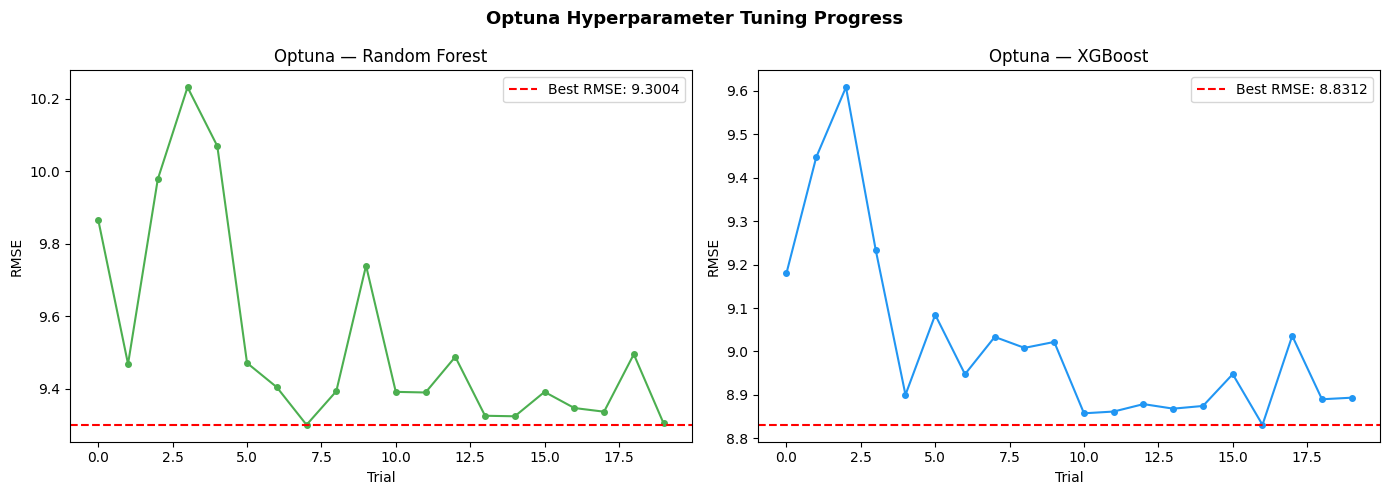

In [ ]:
# Visualisasi Optuna optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_vals  = [-t.value for t in study_rf.trials]
xgb_vals = [-t.value for t in study_xgb.trials]

axes[0].plot(rf_vals, marker='o', color='#4CAF50', linewidth=1.5, markersize=4)
axes[0].axhline(-study_rf.best_value, color='red', linestyle='--',
                label=f'Best RMSE: {-study_rf.best_value:.4f}')
axes[0].set_title('Optuna — Random Forest')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('RMSE')
axes[0].legend()

axes[1].plot(xgb_vals, marker='o', color='#2196F3', linewidth=1.5, markersize=4)
axes[1].axhline(-study_xgb.best_value, color='red', linestyle='--',
                label=f'Best RMSE: {-study_xgb.best_value:.4f}')
axes[1].set_title('Optuna — XGBoost')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.suptitle('Optuna Hyperparameter Tuning Progress', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Evaluasi & Perbandingan Model

=== Perbandingan Semua Model ===


,MSE,RMSE,MAE,R2
Ridge_baseline,85.685300,9.256600,6.623800,0.222100
RF_baseline,83.003400,9.110600,6.538900,0.246500
XGB_baseline,75.249500,8.674600,6.144500,0.316900
RF_optuna,81.302000,9.016800,6.540300,0.261900
XGB_optuna,72.445500,8.511500,6.028200,0.342300


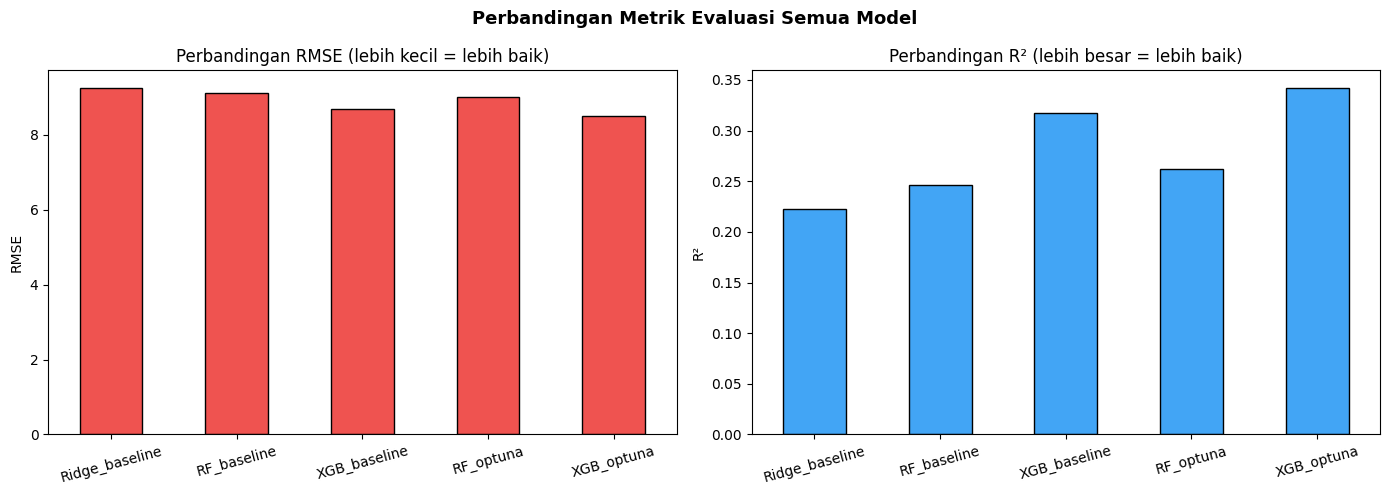

In [ ]:
# Tabel perbandingan semua model
comparison_df = pd.DataFrame({
    name: {k: v for k, v in m.items() if k not in ['model', 'run_id', 'y_pred']}
    for name, m in results.items()
}).T.round(4)

print('=== Perbandingan Semua Model ===')
display(comparison_df.style
    .highlight_min(subset=['RMSE', 'MAE', 'MSE'], axis=0, color='#a8f0a8')
    .highlight_max(subset=['R2'], axis=0, color='#a8f0a8')
)

# Bar chart RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison_df['RMSE'].plot(kind='bar', ax=axes[0], color='#EF5350', edgecolor='black')
axes[0].set_title('Perbandingan RMSE (lebih kecil = lebih baik)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=15)

comparison_df['R2'].plot(kind='bar', ax=axes[1], color='#42A5F5', edgecolor='black')
axes[1].set_title('Perbandingan R² (lebih besar = lebih baik)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Perbandingan Metrik Evaluasi Semua Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

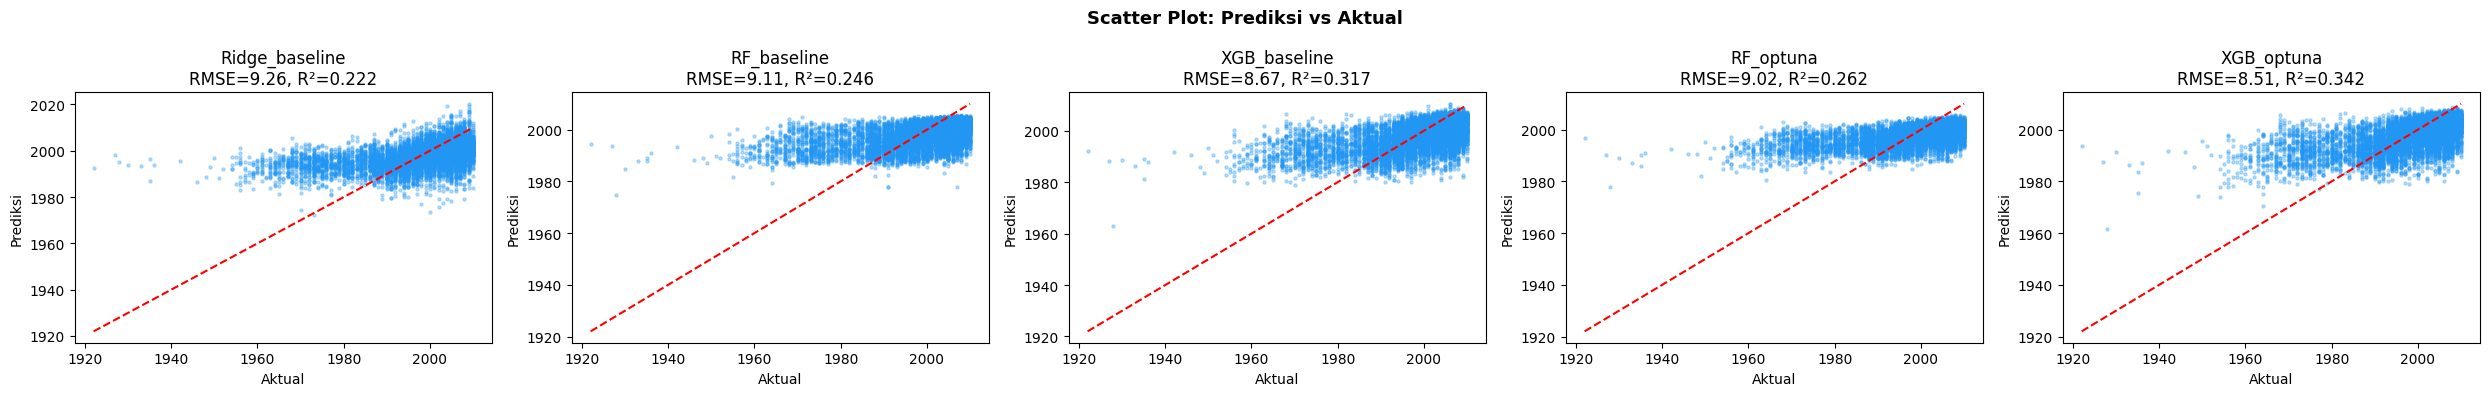

In [ ]:
# Scatter plot: Prediksi vs Aktual
best_name  = min(results, key=lambda x: results[x]['RMSE'])
best_model = results[best_name]['model']
y_pred_best = results[best_name]['y_pred']

fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 4))
if len(results) == 1:
    axes = [axes]

for ax, (name, m) in zip(axes, results.items()):
    ax.scatter(y_val, m['y_pred'], alpha=0.3, s=5, color='#2196F3')
    ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', linewidth=1.5)
    ax.set_title(f'{name}\nRMSE={m["RMSE"]:.2f}, R²={m["R2"]:.3f}')
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')

plt.suptitle('Scatter Plot: Prediksi vs Aktual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

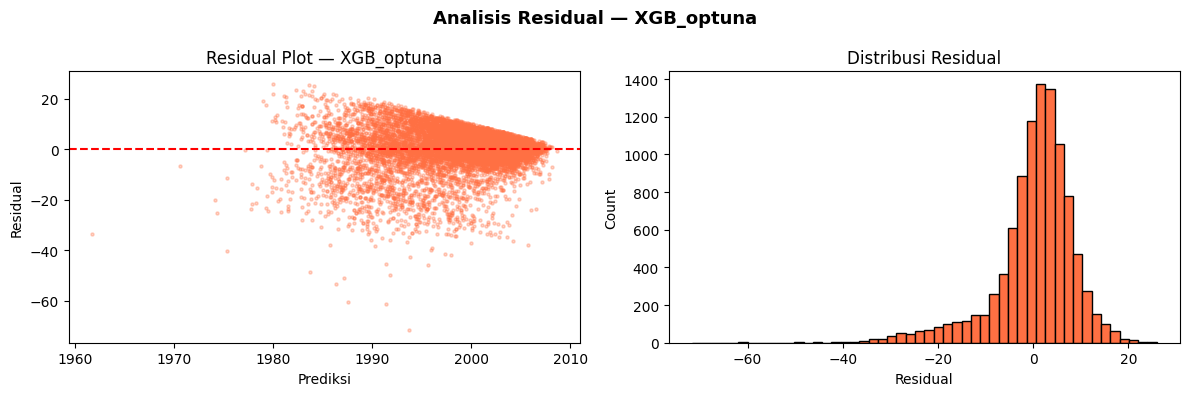

In [ ]:
# Residual plot model terbaik
residuals = y_val.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=5, color='#FF7043')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Residual Plot — {best_name}')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Residual')

axes[1].hist(residuals, bins=50, color='#FF7043', edgecolor='black')
axes[1].set_title('Distribusi Residual')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')

plt.suptitle(f'Analisis Residual — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

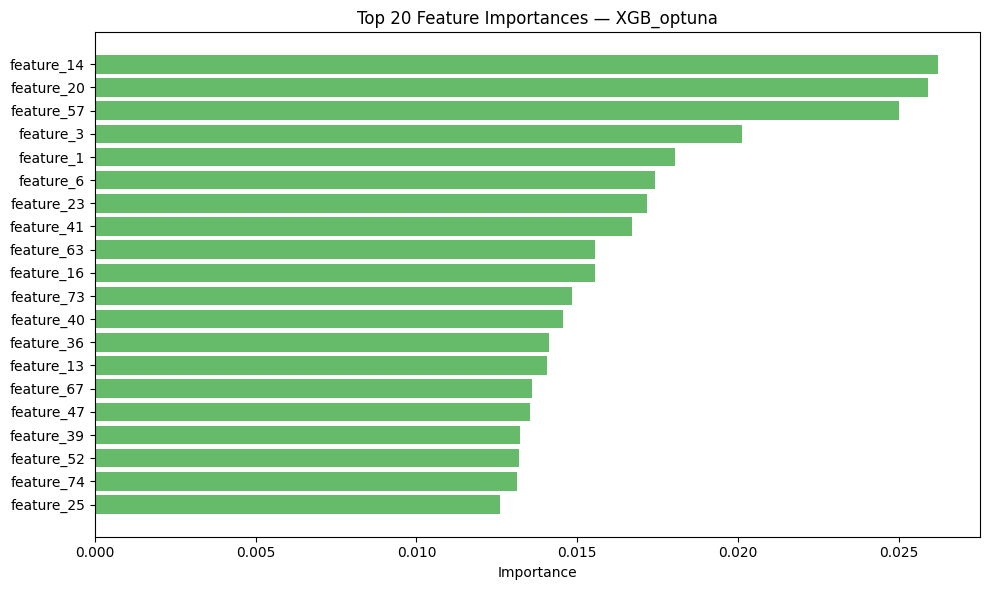

In [ ]:
# Feature importance model terbaik
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.DataFrame({
        'Feature'   : feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='#66BB6A')
    plt.xlabel('Importance')
    plt.title(f'Top 20 Feature Importances — {best_name}')
    plt.tight_layout()
    plt.show()

## 9. Interpretasi dengan LIME

**LIME (Local Interpretable Model-agnostic Explanations)** digunakan untuk menjelaskan **mengapa** model membuat prediksi tertentu untuk sebuah data point. LIME membuat model lokal yang sederhana di sekitar data point tersebut untuk mengidentifikasi fitur mana yang paling berpengaruh.

In [ ]:
# Setup LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train,
    feature_names  = feature_names,
    mode           = 'regression',
    random_state   = SEED
)

print('✅ LIME explainer siap')

✅ LIME explainer siap



===== LIME Explanation: Prediksi Rendah =====
  Tahun Aktual   : 1928
  Tahun Prediksi : 1961.7


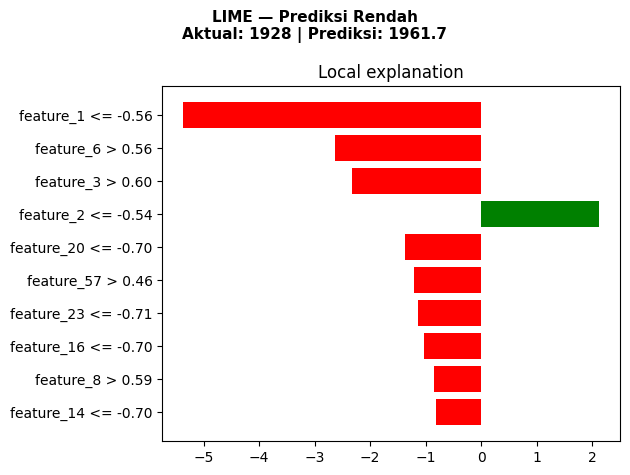


===== LIME Explanation: Prediksi Tengah =====
  Tahun Aktual   : 1988
  Tahun Prediksi : 1998.3


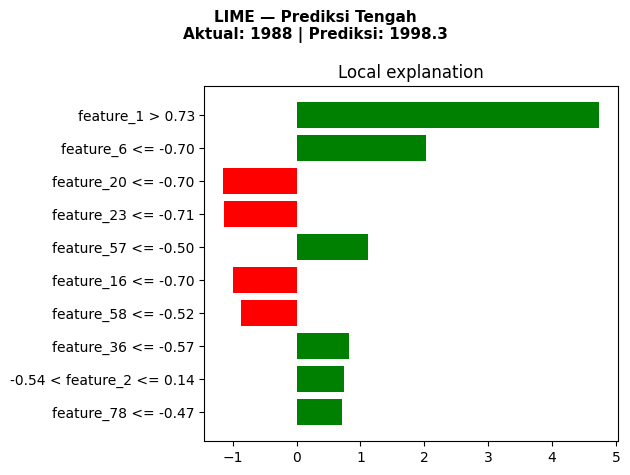


===== LIME Explanation: Prediksi Tinggi =====
  Tahun Aktual   : 2008
  Tahun Prediksi : 2008.6


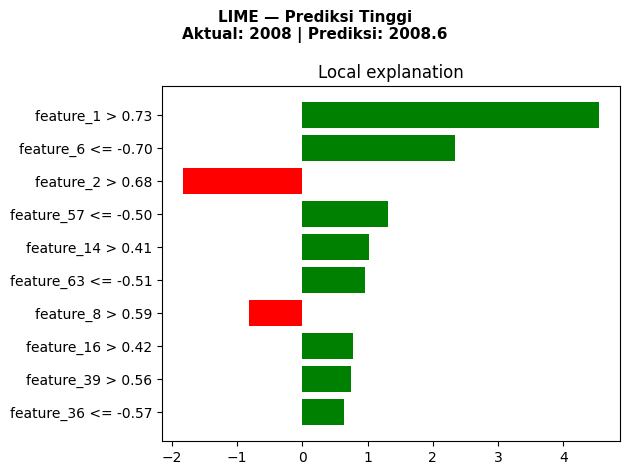

In [ ]:
# Pilih 3 sampel untuk dijelaskan: prediksi rendah, tengah, tinggi
y_pred_arr = np.array(results[best_name]['y_pred'])
idx_low    = np.argmin(y_pred_arr)                        # prediksi tahun terendah
idx_mid    = np.argmin(np.abs(y_pred_arr - y_pred_arr.mean()))  # prediksi paling rata-rata
idx_high   = np.argmax(y_pred_arr)                        # prediksi tahun tertinggi

sample_indices = {'Prediksi Rendah': idx_low,
                  'Prediksi Tengah': idx_mid,
                  'Prediksi Tinggi': idx_high}

for label, idx in sample_indices.items():
    exp = explainer.explain_instance(
        data_row       = X_val[idx],
        predict_fn     = best_model.predict,
        num_features   = 10
    )
    actual    = y_val.iloc[idx]
    predicted = y_pred_arr[idx]

    print(f'\n===== LIME Explanation: {label} =====')
    print(f'  Tahun Aktual   : {actual:.0f}')
    print(f'  Tahun Prediksi : {predicted:.1f}')

    fig = exp.as_pyplot_figure()
    fig.suptitle(f'LIME — {label}\nAktual: {actual:.0f} | Prediksi: {predicted:.1f}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Interpretasi Hasil

Isi bagian ini setelah notebook selesai dijalankan:

**Model Terbaik**: [tulis nama model dengan RMSE terendah]

**Perbandingan Metrik**:
| Model | RMSE | MAE | R² |
|---|---|---|---|
| Ridge baseline | — | — | — |
| RF baseline | — | — | — |
| XGB baseline | — | — | — |
| RF Optuna | — | — | — |
| XGB Optuna | — | — | — |

**Insight LIME**:
- Fitur yang paling berpengaruh untuk prediksi tahun rendah: [...]
- Fitur yang paling berpengaruh untuk prediksi tahun tinggi: [...]
- LIME membantu kita memahami bahwa model tidak hanya black-box, tapi bisa dijelaskan secara lokal per data point

**Catatan**:
- RMSE dalam satuan tahun — artinya rata-rata error prediksi model adalah [...] tahun
- R² = [...] artinya model mampu menjelaskan [...]% variasi tahun rilis lagu

## 10. MLflow Tracking Summary

In [ ]:
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.RMSE ASC']
)

cols_show = ['tags.mlflow.runName', 'metrics.RMSE', 'metrics.MAE',
             'metrics.R2', 'metrics.MSE']
cols_show = [c for c in cols_show if c in runs_df.columns]

print('=== MLflow Runs (sorted by RMSE) ===')
display(runs_df[cols_show].rename(
    columns=lambda x: x.replace('metrics.', '').replace('tags.mlflow.', '')
))

print(f'\n🏆 Best model: {best_name}')
print(f'   RMSE : {results[best_name]["RMSE"]:.4f} tahun')
print(f'   R²   : {results[best_name]["R2"]:.4f}')
print('\n✅ Pipeline selesai!')

=== MLflow Runs (sorted by RMSE) ===


,runName,RMSE,MAE,R2,MSE
0,XGB_optuna,8.511491,6.028195,0.342319,72.445473
1,XGB_baseline,8.674649,6.144535,0.316864,75.249527
2,RF_optuna,9.016765,6.540256,0.261917,81.302048
3,RF_baseline,9.110620,6.538893,0.246472,83.003405
4,Ridge_baseline,9.256634,6.623822,0.222125,85.685270



🏆 Best model: XGB_optuna
   RMSE : 8.5115 tahun
   R²   : 0.3423

✅ Pipeline selesai!
